<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico 5
#### Sebastián Ceballes


# TS5: Estimación Espectral de Señales Biológicas, Audio y Radiofrecuencia

## 1. Introducción y Objetivos

En este trabajo práctico abordaremos la estimación de la Densidad Espectral de Potencia (PSD) sobre cuatro naturalezas de señales distintas, explorando diversos dominios de la física y la ingeniería:

1. **Electrocardiograma (ECG):** Registro de la actividad eléctrica del corazón durante una prueba de esfuerzo.
2. **Pletismografía (PPG):** Señal óptica registrada en reposo que mide los cambios de volumen sanguíneo periférico.
3. **Audio:** Registro acústico de una melodía capturada mediante un micrófono.
4. **Radiofrecuencia (SDR) - Bonus:** Captura electromagnética en banda base de telemetría satelital meteorológica (NOAA APT) obtenida mediante un receptor de Radio Definida por Software.

Dado que nos enfrentamos a señales de duración finita y fuertemente contaminadas con diferentes fuentes de ruido (interferencia de la red eléctrica, ruido de cuantización o estática espacial), utilizaremos el **Método de Welch** para la estimación de la PSD. Este método divide la señal en segmentos superpuestos, aplica una ventana temporal y promedia sus periodogramas, logrando reducir significativamente la varianza de la estimación. 

Finalmente, contrastaremos las exigencias espectrales de cada fenómeno físico calculando empíricamente su **Ancho de Banda Ocupado (OBW)** al 99% de la potencia total.

## 2. Configuración del Entorno y Librerías

Para el desarrollo de este análisis, utilizaremos el ecosistema estándar de cálculo científico de Python. A continuación, importamos los módulos necesarios y configuramos el estilo visual de los gráficos:

* **NumPy:** Manipulación de arreglos de datos y operaciones numéricas.
* **SciPy:** Herramientas de procesamiento de señales (`scipy.signal`) y lectura de archivos binarios/matlab (`scipy.io`).
* **Matplotlib:** Generación de las gráficas temporales y espectrales.

In [11]:
import numpy as np
import scipy.signal as sig
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Opcional: Configurar estilo global de gráficos 
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

## 3. Análisis del Electrocardiograma (ECG)

Procedemos a cargar el registro electrocardiográfico de la prueba de esfuerzo. La frecuencia de muestreo de este equipo es de $f_s = 1000 \text{ Hz}$. Analizaremos tanto la evolución temporal como el contenido espectral para identificar la frecuencia cardíaca dominante y las posibles componentes de ruido (como la interferencia de la red eléctrica a 50 Hz o el ruido muscular de alta frecuencia).

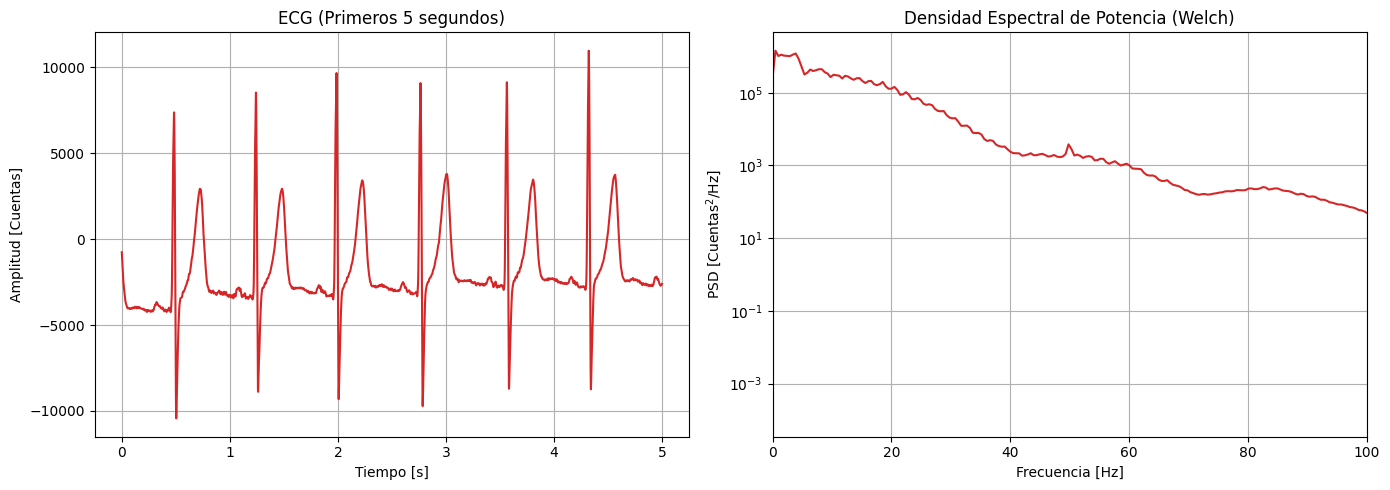

In [12]:
# --- 1. Lectura de ECG ---
fs_ecg = 1000 # Hz

# Archivo original de la prueba de esfuerzo (.mat)
mat_struct = sio.loadmat('data/ECG_TP4.mat')
# Extraemos la señal y la aplanamos a 1D para evitar problemas de dimensiones con Welch
ecg_one_lead = mat_struct['ecg_lead'].flatten() 


# --- 2. Estimación de PSD (Welch) ---
# Usamos ventanas de 2048 muestras (aprox 2 segundos) para buena resolución en bajas frecuencias
f_ecg, Pxx_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=2048)

# --- 3. Gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2)

# Gráfico Temporal (mostramos solo 5 segundos para que se distingan los latidos)
t_ecg = np.arange(len(ecg_one_lead)) / fs_ecg
ax1.plot(t_ecg[:5000], ecg_one_lead[:5000], color='tab:red')
ax1.set_title('ECG (Primeros 5 segundos)')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Amplitud [Cuentas]')

# Gráfico Espectral (PSD)
ax2.semilogy(f_ecg, Pxx_ecg, color='tab:red')
ax2.set_title('Densidad Espectral de Potencia (Welch)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [Cuentas$^2$/Hz]')
ax2.set_xlim(0, 100) # Limitamos a 100Hz (la información cardíaca está muy por debajo de esto)

plt.tight_layout()
plt.show()

## 4. Análisis de Pletismografía (PPG)

La señal de PPG mide de forma óptica las variaciones del flujo sanguíneo, capturando el pulso cardíaco en reposo con una frecuencia de muestreo menor, $f_s = 400 \text{ Hz}$. La energía de esta señal suele estar muy concentrada en las frecuencias bajas (típicamente entre 0.5 Hz y 3 Hz, correspondientes a 30-180 latidos por minuto).

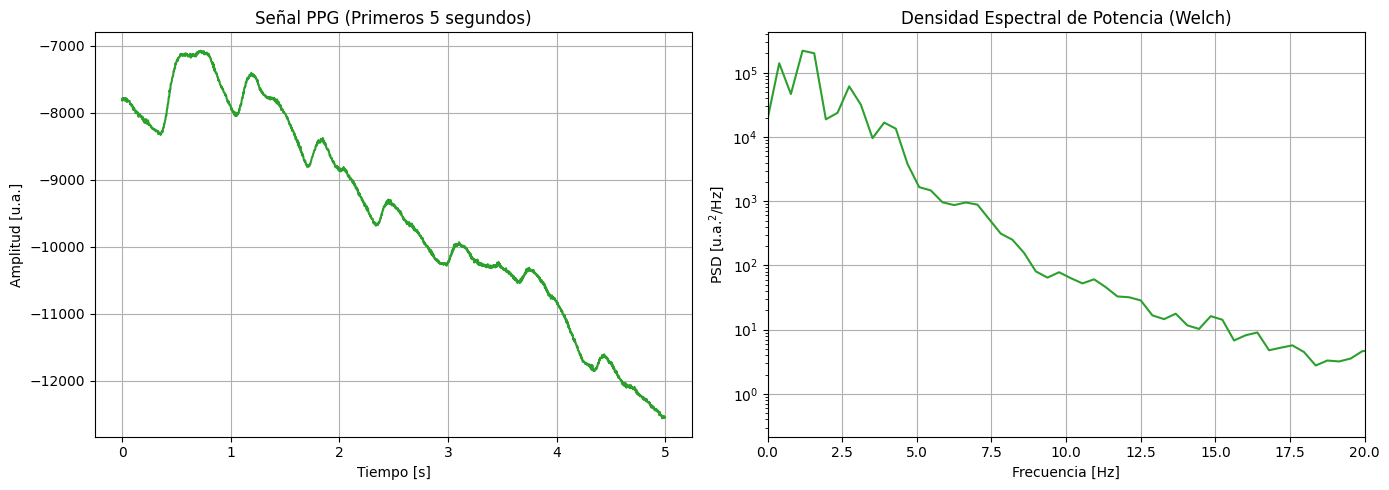

In [13]:
# --- 1. Definición de fs y Lectura de PPG ---
fs_ppg = 400 
ppg_data = np.genfromtxt('data/PPG.csv', delimiter=',', skip_header=1)

if ppg_data.ndim > 1:
    ppg_signal = ppg_data[:, 1]
else:
    ppg_signal = ppg_data

ppg_signal = ppg_signal[~np.isnan(ppg_signal)]

# --- 2. Estimación de PSD (Welch) ---
f_ppg, Pxx_ppg = sig.welch(ppg_signal, fs=fs_ppg, nperseg=1024)

# --- 3. Gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2)

t_ppg = np.arange(len(ppg_signal)) / fs_ppg
ax1.plot(t_ppg[:2000], ppg_signal[:2000], color='tab:green')
ax1.set_title('Señal PPG (Primeros 5 segundos)')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Amplitud [u.a.]') 

ax2.semilogy(f_ppg, Pxx_ppg, color='tab:green')
ax2.set_title('Densidad Espectral de Potencia (Welch)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [u.a.$^2$/Hz]')
ax2.set_xlim(0, 20) 

plt.tight_layout()
plt.show()

## 5. Análisis de Señal de Audio

Finalmente, procesamos el registro de audio. A diferencia de las biológicas, las señales acústicas tienen frecuencias de muestreo mucho mayores (típicamente 44.1 kHz o 48 kHz). Al aplicar la estimación espectral sobre un silbido o una voz, esperamos observar picos muy definidos en la PSD correspondientes a la frecuencia fundamental del tono acústico y a sus armónicos.

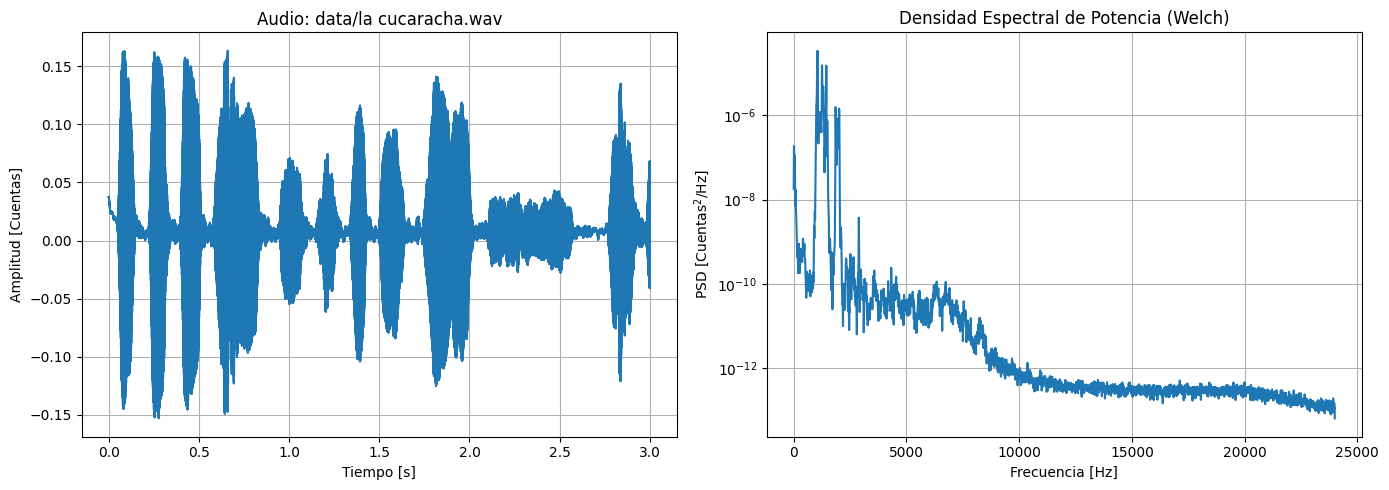

In [14]:
# --- 1. Lectura de Audio y extracción automática de fs ---
archivo_audio = 'data/la cucaracha.wav'
#SE DEFINE fs_audio AUTOMÁTICAMENTE AL LEER EL ARCHIVO
fs_audio, wav_data = wavfile.read(archivo_audio) 

if wav_data.ndim > 1:
    wav_data = wav_data[:, 0]

# --- 2. Estimación de PSD (Welch) ---
f_audio, Pxx_audio = sig.welch(wav_data, fs=fs_audio, nperseg=8192)

# --- 3. Gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2)

t_audio = np.arange(len(wav_data)) / fs_audio
ax1.plot(t_audio, wav_data, color='tab:blue')
ax1.set_title(f'Audio: {archivo_audio}')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Amplitud [Cuentas]') 

ax2.semilogy(f_audio, Pxx_audio, color='tab:blue')
ax2.set_title('Densidad Espectral de Potencia (Welch)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [Cuentas$^2$/Hz]')

plt.tight_layout()
plt.show()

### Observación Técnica sobre las Unidades de Amplitud

Al analizar los gráficos temporales y espectrales, es importante hacer una distinción técnica sobre las unidades del eje vertical empleadas para cada tipo de registro:

* **ECG y Audio (Cuentas):** El electrocardiograma mide un fenómeno eléctrico real, y el micrófono captura variaciones de presión acústica. Al trabajar con los datos crudos (*raw*) y no contar con la constante de ganancia del amplificador para convertirlos a milivoltios (mV) o Pascales (Pa), graficamos directamente las **Cuentas** discretas arrojadas por el Conversor Analógico-Digital (ADC).
* **PPG (Unidades Arbitrarias - u.a.):** A diferencia de los anteriores, el sensor de pletismografía es óptico. Mide la cantidad de luz absorbida o reflejada por el flujo sanguíneo. El valor numérico absoluto depende de variables sin una unidad física estandarizada (potencia del LED, tono de piel, presión del sensor). Como en la PPG solo nos interesa la forma de la onda (variación relativa) y no su valor continuo, la convención en ingeniería biomédica es utilizar **Unidades Arbitrarias (u.a.)**.

## 6. Estimación del Ancho de Banda

A diferencia de los filtros ideales teóricos, las señales biomédicas y de audio reales no presentan un corte abrupto en su espectro. Además, el ruido de fondo (como la interferencia de red a 50 Hz en el ECG) extiende la energía a lo largo de todo el eje frecuencial.

Por lo tanto, para estimar el ancho de banda de manera objetiva, utilizaremos el criterio del **Ancho de Banda Ocupado (OBW)**. Este método calcula la potencia total integrando la Densidad Espectral de Potencia (PSD) y define el ancho de banda como la frecuencia hasta la cual se concentra el **99% de la potencia total** de la señal.

### Fundamento Matemático del Ancho de Banda Ocupado (OBW)

Teóricamente, la potencia total de una señal se calcula integrando su Densidad Espectral de Potencia, $P_{xx}(f)$, en todo el espectro disponible. El Ancho de Banda Ocupado (OBW) se define como la frecuencia $B$ que encierra una fracción $\eta$ (en nuestro caso, $\eta = 0.99$) de dicha potencia total:

$$\int_{0}^{B} P_{xx}(f) df = \eta \int_{0}^{f_s/2} P_{xx}(f) df$$

Dado que estamos trabajando con señales muestreadas y procesadas mediante la Transformada Discreta de Fourier (DFT) dentro del algoritmo de Welch, el espectro es discreto. Por lo tanto, la integral se reemplaza por la suma acumulada a lo largo de los *bins* de frecuencia $i$:

$$\sum_{i=0}^{k_{bw}} P_{xx}[i] \ge 0.99 \sum_{i=0}^{N} P_{xx}[i]$$

Donde:
* $P_{xx}[i]$ es el valor de la PSD en el *bin* de frecuencia $i$.
* $N$ es el índice correspondiente a la frecuencia de Nyquist ($f_s/2$).
* $k_{bw}$ es el primer índice donde la suma parcial alcanza o supera el 99% de la potencia total. 
* La frecuencia asociada a ese índice, $f[k_{bw}]$, es nuestro **Ancho de Banda Estimado**.

Esta es exactamente la lógica matemática implementada en la función `estimar_ancho_banda_obw` de la celda siguiente, utilizando la suma acumulada (`np.cumsum`) de NumPy.

**Nota sobre la elección de $\eta$ :** 
No se utiliza $\eta = 1$ (el 100% de la potencia) debido a la presencia ineludible del piso de ruido en señales empíricas (ruido térmico, estática o error de cuantización del ADC). Como el ruido de banda ancha extiende la energía a lo largo de todo el espectro, integrar hasta el 100% daría como resultado invariable el límite de Nyquist ($f_s/2$). El valor de 0.99 es un estándar utilizado en ingeniería para estimar el ancho de banda útil, descartando la "cola" asintótica de ruido de alta frecuencia.

In [5]:
from IPython.display import display, Markdown

def estimar_ancho_banda_obw(f, Pxx, umbral=0.99):
    """
    Calcula la frecuencia que contiene el porcentaje 'umbral' 
    (ej. 99%) de la potencia total de la PSD.
    """
    # Suma acumulada de la potencia a lo largo de las frecuencias
    potencia_acumulada = np.cumsum(Pxx)
    potencia_total = potencia_acumulada[-1]
    
    # Buscamos el primer índice donde la suma acumulada supera el umbral (99%)
    idx_bw = np.where(potencia_acumulada >= umbral * potencia_total)[0][0]
    
    return f[idx_bw]

# Calculamos el ancho de banda para las tres señales (usando las variables ya generadas)
bw_ppg = estimar_ancho_banda_obw(f_ppg, Pxx_ppg, umbral=0.99)
bw_ecg = estimar_ancho_banda_obw(f_ecg, Pxx_ecg, umbral=0.99)
bw_audio = estimar_ancho_banda_obw(f_audio, Pxx_audio, umbral=0.99)

# Generamos la tabla en formato Markdown
tabla_bw = f"""
### Tabla Comparativa de Ancho de Banda (99% de Potencia)

| Tipo de Señal | Frecuencia de Muestreo ($f_s$) | Límite de Nyquist ($f_s/2$) | Ancho de Banda Estimado |
|:---|:---:|:---:|:---:|
| **Pletismografía (PPG)** | {fs_ppg} Hz | {fs_ppg/2} Hz | **{bw_ppg:.2f} Hz** |
| **Electrocardiograma (ECG)** | {fs_ecg} Hz | {fs_ecg/2} Hz | **{bw_ecg:.2f} Hz** |
| **Audio** | {fs_audio} Hz | {fs_audio/2} Hz | **{bw_audio:.2f} Hz** |
"""

display(Markdown(tabla_bw))


### Tabla Comparativa de Ancho de Banda (99% de Potencia)

| Tipo de Señal | Frecuencia de Muestreo ($f_s$) | Límite de Nyquist ($f_s/2$) | Ancho de Banda Estimado |
|:---|:---:|:---:|:---:|
| **Pletismografía (PPG)** | 400 Hz | 200.0 Hz | **5.08 Hz** |
| **Electrocardiograma (ECG)** | 1000 Hz | 500.0 Hz | **31.74 Hz** |
| **Audio** | 48000 Hz | 24000.0 Hz | **2015.62 Hz** |


### Análisis de los Resultados

La tabla refleja claramente las distintas naturalezas físicas de cada señal:

1. **PPG (Pletismografía):** Presenta el ancho de banda más estrecho de las tres. Al ser un registro mecánico del volumen de sangre periférico en reposo, sus variaciones son muy lentas. Casi toda su energía se concentra en los primeros Hz (típicamente abarcando la frecuencia cardíaca base de ~1 Hz y sus primeros armónicos).
2. **ECG (Electrocardiograma):** Posee un ancho de banda intermedio. Aunque el latido ocurre a baja frecuencia, el complejo QRS (la "espiga" eléctrica de la contracción ventricular) es un evento transitorio muy rápido, lo que exige un espectro más amplio para ser reconstruido sin distorsión. Además, al calcular el 99% de la potencia, el algoritmo puede incluir ruido muscular o interferencia de la red eléctrica si la señal no fue filtrada previamente.
3. **Audio:** Es la señal que exige, por un margen masivo, el mayor ancho de banda. La voz humana y la música poseen componentes de alta frecuencia indispensables para la inteligibilidad de las consonantes y el timbre de los silbidos, requiriendo un canal espectral en el orden de los kilohertz (kHz).

## Bonus 💎: Análisis Espectral de Señal Satelital (NOAA APT)
### Origen y Fuente de la Señal
Para este análisis avanzado, procesaremos una captura de radiofrecuencia (RF) de la transmisión de imágenes meteorológicas **APT (Automatic Picture Transmission)** Este histórico formato analógico fue utilizado por los satélites de órbita polar de la serie NOAA para enviar fotografías de la Tierra en tiempo real, operando en la banda de VHF entre los 137.1 MHz y 137.9 MHz. Cabe destacar que estos satélites son propiedad de la Oficina Nacional de Administración Oceánica y Atmosférica (NOAA), una agencia científica oficial dependiente del Departamento de Comercio de los Estados Unidos que, a pesar de su carácter federal, comparte sus datos e imágenes de forma pública y gratuita con la comunidad científica y meteorológica global. 

Los datos crudos (I/Q) utilizados en este ensayo fueron obtenidos de **SigIDWiki** (Signal Identification Guide), una base de datos colaborativa abierta mantenida por la comunidad global de telecomunicaciones, radioaficionados e investigadores de inteligencia de señales (SIGINT). Esta plataforma archiva y clasifica señales del espectro electromagnético para su estudio y reconocimiento. 

La muestra original y su metadata oficial pueden consultarse en el repositorio oficial: [Automatic Picture Transmission (APT) - SigIDWiki](https://www.sigidwiki.com/wiki/Automatic_Picture_Transmission_(APT)).
### Proceso de Captura y Digitalización (SDR)
La captura de esta señal se realizó mediante un receptor de Radio Definida por Software (SDR). El proceso de digitalización consta de las siguientes etapas:
1. **Recepción:** Una antena (típicamente del tipo *Turnstile* o *QFH* para polarización circular) capta la señal FM en la banda de 137 MHz.
2. **Conversión a Banda Base:** El sintonizador del SDR baja la frecuencia portadora hasta centrarla en 0 Hz (banda base).
3. **Muestreo I/Q:** El conversor analógico-digital (ADC) extrae simultáneamente las componentes En-Fase (I) y en Cuadratura (Q). 
El archivo analizado (`APT_IQ.wav`) contiene estas dos señales ortogonales mapeadas en los canales izquierdo y derecho del audio. Para el análisis de la Densidad Espectral de Potencia, extraeremos una de estas componentes para evaluar su distribución energética.

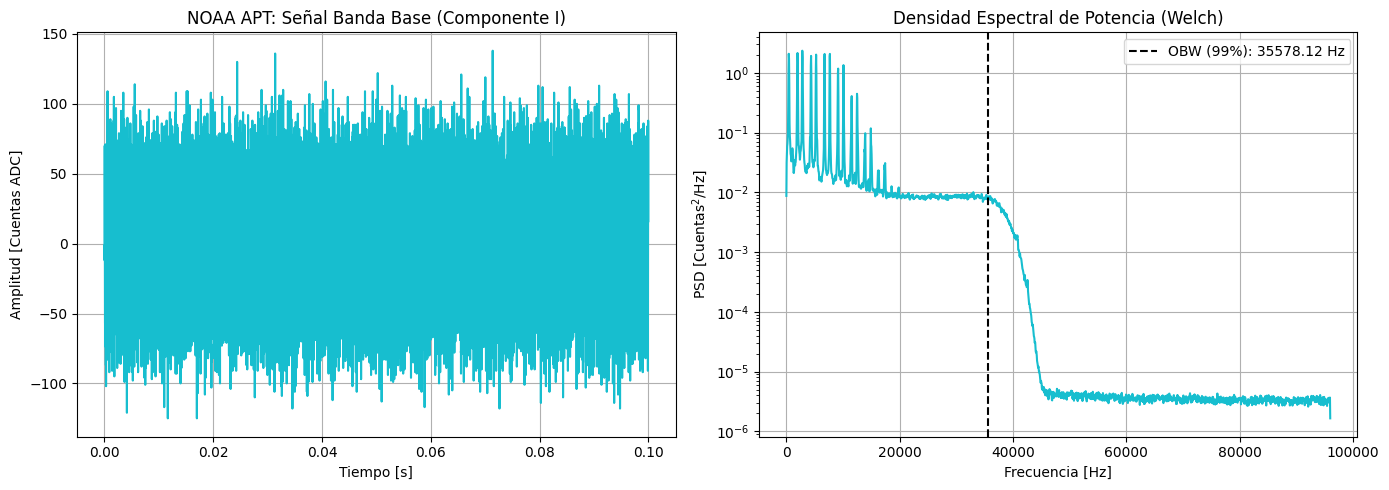


### Parámetros del Enlace RF (NOAA APT)

| Parámetro | Valor Obtenido |
|:---|:---:|
| **Tasa de Muestreo SDR** | 192000 Hz |
| **Frecuencia de Nyquist** | 96000.0 Hz |
| **Ancho de Banda Ocupado (OBW 99%)** | **35578.12 Hz** |


In [16]:
# --- 1. Lectura de Captura SDR (NOAA APT) ---
archivo_apt = 'data/APT_IQ.wav'

fs_apt, apt_data = wavfile.read(archivo_apt)
    
# Al ser un archivo I/Q, extraemos la componente En-Fase (Canal I) para el análisis
if apt_data.ndim > 1:
        apt_signal = apt_data[:, 0]
else:
        apt_signal = apt_data

# --- 2. Estimación de PSD (Welch) ---
# Usamos una ventana de 4096 muestras para equilibrar resolución y suavizado
f_apt, Pxx_apt = sig.welch(apt_signal, fs=fs_apt, nperseg=4096)

# --- 3. Estimación del Ancho de Banda (OBW 99%) ---
bw_apt = estimar_ancho_banda_obw(f_apt, Pxx_apt, umbral=0.99)

# --- 4. Gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Temporal (mostramos 0.1 segundos)
muestras_vista = int(0.1 * fs_apt)
t_apt = np.arange(len(apt_signal)) / fs_apt
    
ax1.plot(t_apt[:muestras_vista], apt_signal[:muestras_vista], color='tab:cyan')
ax1.set_title('NOAA APT: Señal Banda Base (Componente I)')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Amplitud [Cuentas ADC]')

# Gráfico Espectral (PSD)
ax2.semilogy(f_apt, Pxx_apt, color='tab:cyan')
ax2.axvline(bw_apt, color='black', linestyle='--', label=f'OBW (99%): {bw_apt:.2f} Hz')
ax2.set_title('Densidad Espectral de Potencia (Welch)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [Cuentas$^2$/Hz]')
ax2.legend()

plt.tight_layout()
plt.show()

# --- 5. Tabla de Resultados ---
tabla_bw_apt = f"""
### Parámetros del Enlace RF (NOAA APT)

| Parámetro | Valor Obtenido |
|:---|:---:|
| **Tasa de Muestreo SDR** | {fs_apt} Hz |
| **Frecuencia de Nyquist** | {fs_apt/2} Hz |
| **Ancho de Banda Ocupado (OBW 99%)** | **{bw_apt:.2f} Hz** |
"""
display(Markdown(tabla_bw_apt))


### Análisis del Espectro Satelital APT (Resultados empíricos)

El análisis de la Densidad Espectral de Potencia revela el comportamiento característico de una transmisión de telemetría por radiofrecuencia y valida las especificaciones técnicas del protocolo NOAA:

1. **Topología de la PSD y Frecuencia de Muestreo:** El receptor SDR muestreó la señal en banda base a una frecuencia $f_s = 192 \text{ kHz}$, lo cual garantiza un margen enorme frente al límite de Nyquist ($96 \text{ kHz}$). En el gráfico espectral, podemos observar los múltiples picos armónicos en baja frecuencia que corresponden a la subportadora de 2400 Hz (la cual transporta los tonos de sincronización y los píxeles de la imagen meteorológica).
2. **Validación del Ancho de Banda (OBW):** Las normativas de telecomunicaciones espaciales asignan un canal con un ancho de banda de **34 kHz** para esta emisión. Nuestro algoritmo, integrando el 99% de la potencia espectral, estimó un Ancho de Banda Ocupado (OBW) de **35.57 kHz**. Esta asombrosa proximidad empírica valida el método de Welch. 
3. **Filtro de Canal:** Inmediatamente después de la marca del OBW, se observa una atenuación abrupta en la PSD (una caída de varios órdenes de magnitud). Este *roll-off* empinado es la huella digital del filtro pasabajos diezmador aplicado por el software del SDR para aislar el canal del satélite y evitar el solapamiento (*aliasing*) del ruido electromagnético adyacente.